# Netflix Movies & TV Shows Analysis

## Exploratory Data Analysis (EDA) using Python

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Improve plot appearance
plt.style.use("ggplot")

## 2. Load the Dataset


In [6]:
df = pd.read_csv("netflix_titles.csv")

## 3. Understanding the Dataset

### What does our dataset look like?

In [7]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### How many rows and columns does the dataset contain?

In [8]:
df.shape

(8807, 12)

### What information is available for each title?

In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

### Understanding the data types and missing values

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Statistical summary of numerical columns

In [11]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## 4. Data Cleaning

### Identifying Missing Values

In [21]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


### Checking for Duplicate Records

In [15]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True)

In [18]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["date_added"] = df["date_added"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")

The `duration` column contained only three missing values. Since the missing records represented a very small fraction of the dataset and the correct durations could not be reliably inferred, these rows were removed to maintain data quality.

In [20]:
df = df.dropna(subset=["duration"])

### Business Question 1

How is Netflix's content distributed between Movies and TV Shows?

In [22]:
df["type"].value_counts()

,count
type,
Movie,6128
TV Show,2676


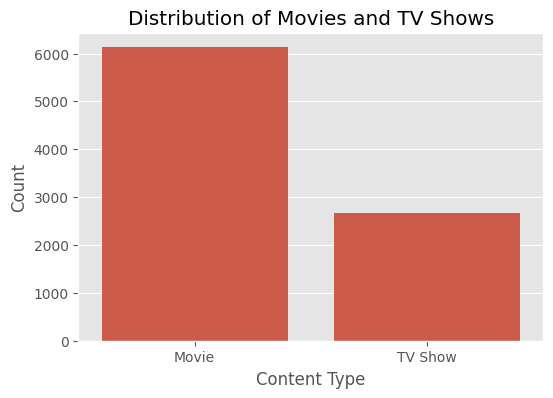

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=df)
plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

### Insight

Movies constitute a significantly larger portion of Netflix's catalog than TV Shows, indicating that Netflix focuses more on movie content than serialized television content.

### Business Question 2

Which countries produce the most Netflix content?

In [24]:
top_countries = df["country"].value_counts().head(10)
top_countries

,count
country,
United States,2815
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


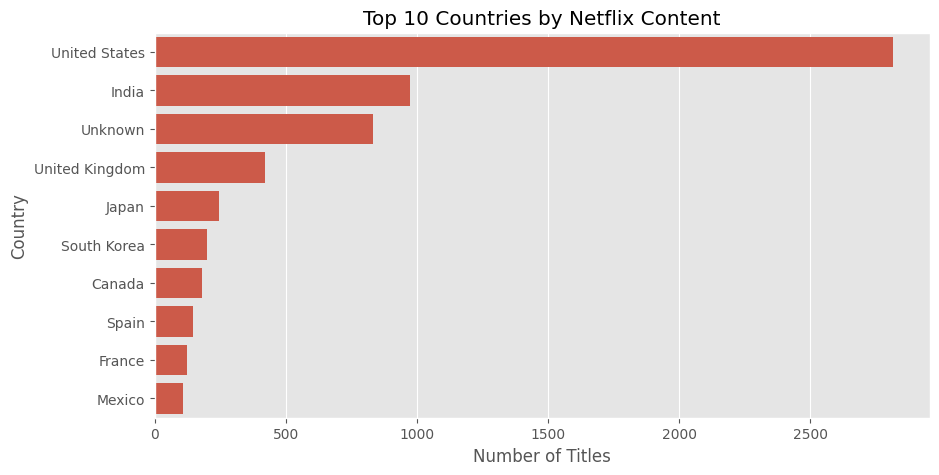

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)
plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

### Insight

The United States contributes the highest number of titles available on Netflix, followed by other major content-producing countries.

### Business Question 3

How has Netflix's content library grown over the years?

In [26]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year
content_growth = df["year_added"].value_counts().sort_index()
content_growth

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,416


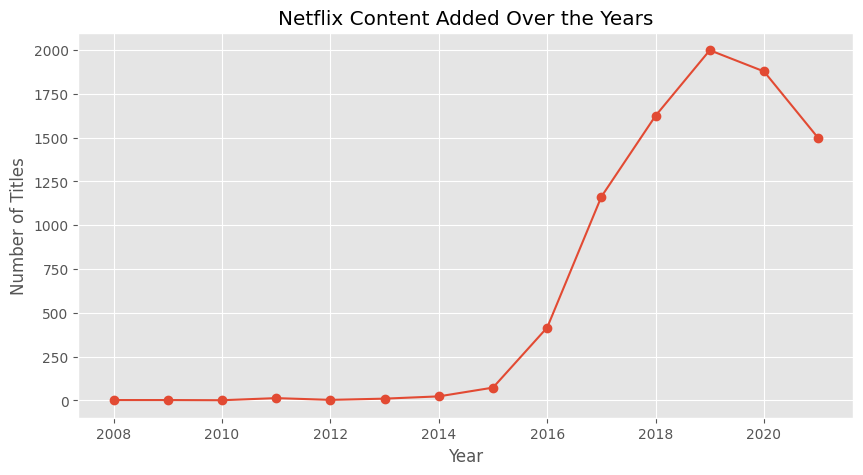

In [27]:
plt.figure(figsize=(10,5))
plt.plot(
    content_growth.index,
    content_growth.values,
    marker="o"
)
plt.title("Netflix Content Added Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

### Insight

Netflix experienced rapid growth in content additions during the late 2010s, reflecting its expansion into global streaming markets.

### Business Question 4

What are the most common content ratings available on Netflix?

In [28]:
rating_counts = df["rating"].value_counts()
rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


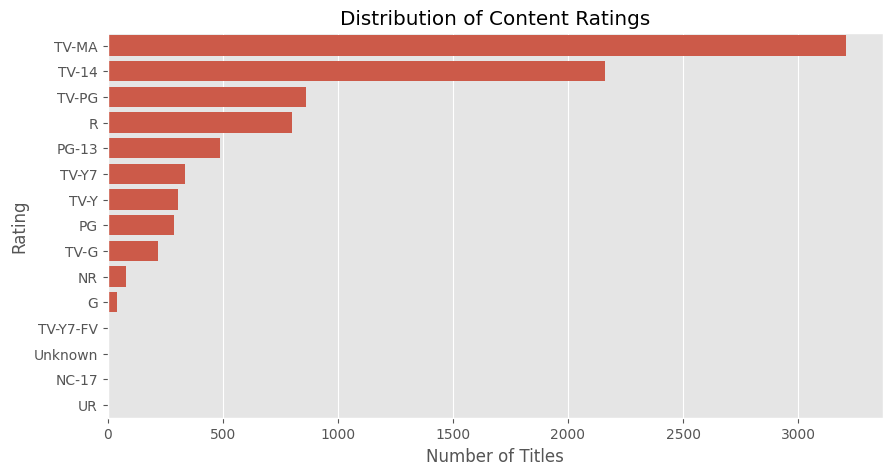

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().index
)
plt.title("Distribution of Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.show()

### Insight

TV-MA and TV-14 are the most common content ratings, indicating that Netflix primarily caters to mature and teenage audiences.

### Business Question 5

Which genres are most frequently available on Netflix?

In [30]:
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)
top_genres = genres.value_counts().head(10)
top_genres

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


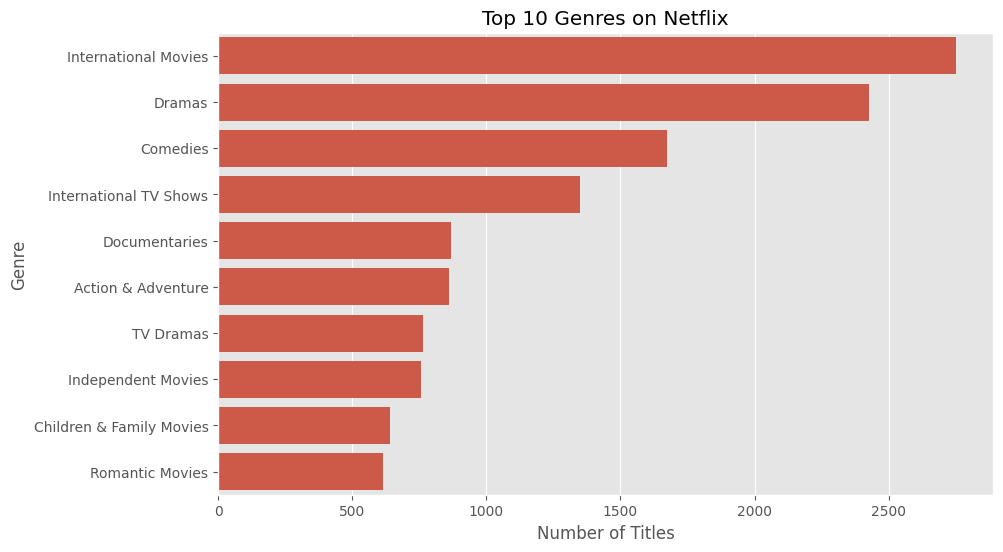

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

### Insight

International Movies, Dramas, and Comedies are among the most popular genres, highlighting Netflix's diverse and globally focused content library.

### Business Question 6

Which directors have contributed the highest number of titles on Netflix?

In [32]:
top_directors = (
    df[df["director"] != "Unknown"]["director"]
    .value_counts()
    .head(10)
)
top_directors

,count
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Jay Chapman,12
Martin Scorsese,12
Youssef Chahine,12


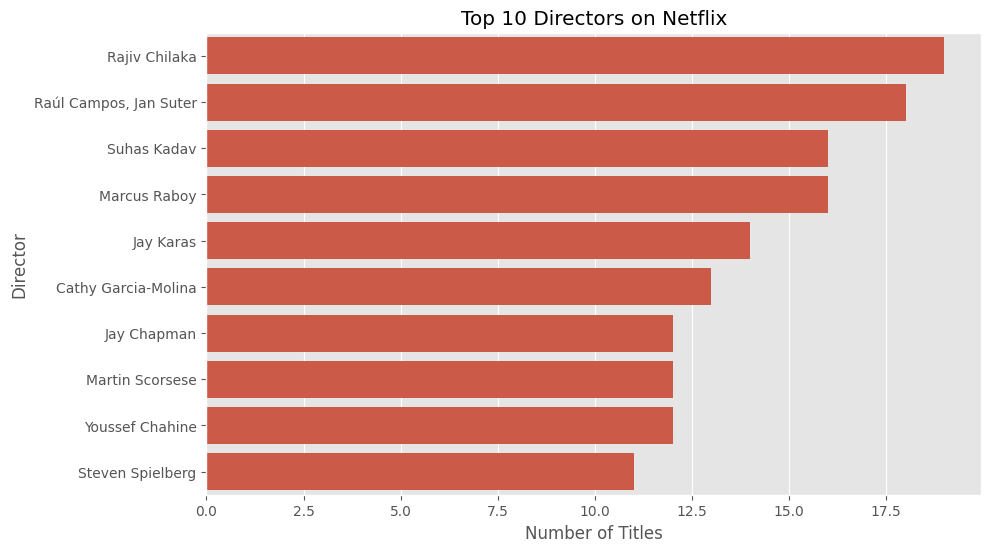

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)
plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

### Insight

A small group of directors contributes multiple titles to Netflix, reflecting recurring collaborations with established filmmakers.

### Business Question 7

What is the distribution of movie durations on Netflix?

In [34]:
movies = df[df["type"] == "Movie"].copy()
movies["duration"] = movies["duration"].str.replace(" min", "", regex=False)
movies["duration"] = movies["duration"].astype(int)

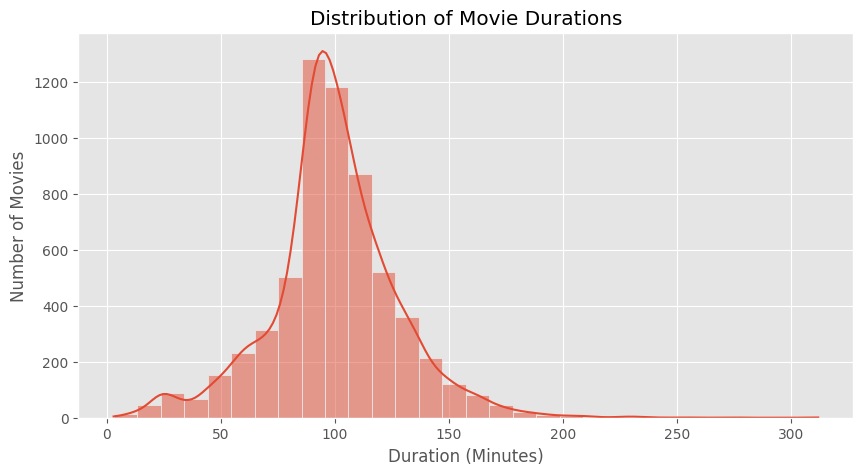

In [35]:
plt.figure(figsize=(10,5))
sns.histplot(
    movies["duration"],
    bins=30,
    kde=True
)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

### Insight

Most Netflix movies have durations between **80 and 120 minutes**, indicating a preference for standard feature-length films.

### Business Question 8

Which months have the highest number of titles added to Netflix?

In [36]:
df["month_added"] = df["date_added"].dt.month_name()
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
monthly = df["month_added"].value_counts().reindex(month_order)

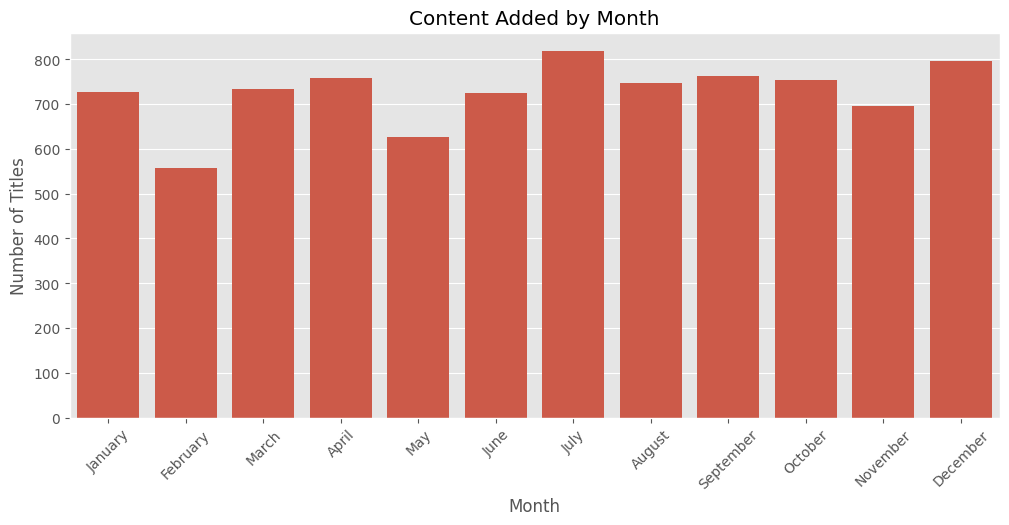

In [37]:
plt.figure(figsize=(12,5))
sns.barplot(
    x=monthly.index,
    y=monthly.values
)
plt.xticks(rotation=45)
plt.title("Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.show()

### Insight

Netflix adds content throughout the year, with certain months showing noticeably higher additions, reflecting periodic content releases.

### Business Question 9

Which release years contributed the highest number of titles available on Netflix?

In [38]:
top_years = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

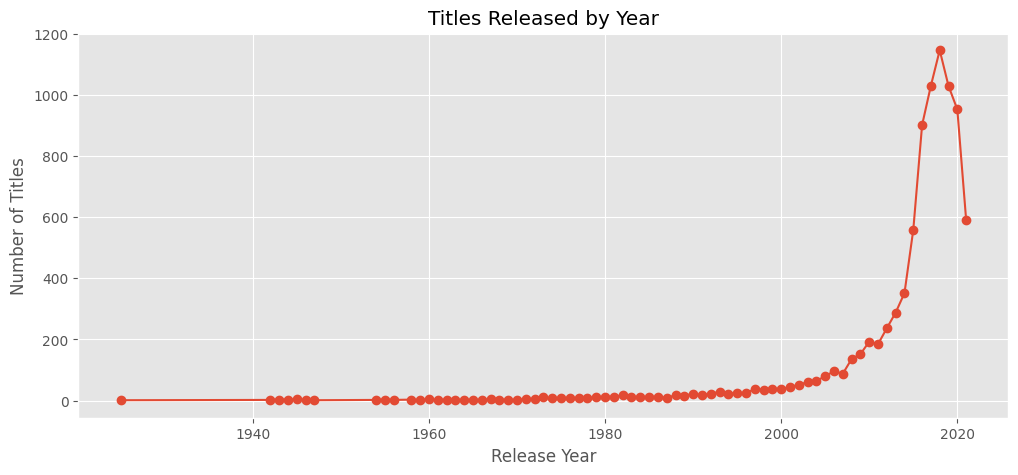

In [39]:
plt.figure(figsize=(12,5))
plt.plot(
    top_years.index,
    top_years.values,
    marker="o"
)
plt.title("Titles Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

### Insight

The number of available titles increases significantly in recent years, reflecting Netflix's focus on acquiring and producing modern content.

# 6. Conclusion

This analysis explored Netflix's content library through Exploratory Data Analysis (EDA). Key insights include:

- Movies significantly outnumber TV Shows on Netflix.
- The United States contributes the largest share of Netflix content.
- Netflix experienced rapid content growth during the late 2010s.
- TV-MA and TV-14 are the most common content ratings.
- International Movies, Dramas, and Comedies dominate the platform.
- Most movies have a duration between 80 and 120 minutes.
- Content is added throughout the year, with seasonal variations.
- Netflix's catalog has expanded considerably with modern releases.

# Key Business Insights

- Movies dominate Netflix's content library.
- The United States is the largest content contributor.
- TV-MA and TV-14 are the most common audience ratings.
- International Movies and Dramas are the most popular genres.
- Most movies have durations between 80–120 minutes.
- Netflix experienced rapid content growth between 2016 and 2020.
